# Sparkle V2 — Fase 5+6: Target de desatención + entrenamiento del LSTM baseline

Este notebook asume que ya corriste la Fase 4 (archivos `train_consolidado.npz`, `validation_consolidado.npz`, `test_consolidado.npz` en Drive).

**Decisión de target (ya cerrada con tu compañero):** usamos **Boredom** colapsado a 3 niveles, porque:
- Engagement está desbalanceado ~95% en 2 de sus 4 clases (inservible tal cual).
- Boredom tiene correlación moderada con Engagement (-0.42), no es la misma señal invertida — aporta información real.
- Colapsando Boredom {0} / {1} / {2,3} queda razonablemente balanceado (~45% / 30% / 24% en Train).

**Qué hace este notebook:**
1. Carga los tensores consolidados de la Fase 4.
2. Construye el target de 3 niveles a partir de Boredom.
3. Normaliza los features (fit del scaler solo en Train, coherente con buenas prácticas — nunca fitear con datos de val/test).
4. Calcula class weights para compensar el desbalance restante durante el entrenamiento (en vez de sumar otro dataset, que decidimos dejar como posible extensión futura).
5. Entrena un LSTM baseline (arquitectura simple, 2 capas).
6. Evalúa en Test con accuracy, F1 por clase y matriz de confusión.
7. Guarda el modelo entrenado y el scaler en Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/SparkleV2'
DATASET_DIR = f'{PROJECT_DIR}/dataset_final'
MODELS_DIR = f'{PROJECT_DIR}/checkpoints'
os.makedirs(MODELS_DIR, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow: 2.20.0
GPU disponible: []


## 1. Cargar los datasets consolidados de la Fase 4

In [2]:
def load_split(split_name):
    data = np.load(f'{DATASET_DIR}/{split_name}_consolidado.npz', allow_pickle=True)
    return {
        'X': data['X'],
        'clip_ids': data['clip_ids'],
        'engagement': data['engagement'],
        'boredom': data['boredom'],
        'confusion': data['confusion'],
        'frustration': data['frustration'],
    }

train = load_split('train')
val = load_split('validation')
test = load_split('test')

print('Train:', train['X'].shape)
print('Validation:', val['X'].shape)
print('Test:', test['X'].shape)

Train: (4851, 60, 5)
Validation: (1429, 60, 5)
Test: (1638, 60, 5)


## 2. Construir el target de 3 niveles a partir de Boredom

- Nivel 0 (Atento): Boredom original = 0
- Nivel 1 (Desatención leve): Boredom original = 1
- Nivel 2 (Desatención marcada): Boredom original = 2 o 3

In [3]:
def collapse_boredom(boredom_array):
    return np.where(boredom_array == 0, 0, np.where(boredom_array == 1, 1, 2)).astype(np.int32)

y_train = collapse_boredom(train['boredom'])
y_val = collapse_boredom(val['boredom'])
y_test = collapse_boredom(test['boredom'])

CLASS_NAMES = ['Atento', 'Desatencion_leve', 'Desatencion_marcada']

for name, y in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    counts = pd.Series(y).value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(1)
    print(f'{name}:')
    for cls in range(3):
        c = counts.get(cls, 0)
        p = pct.get(cls, 0.0)
        print(f'  {CLASS_NAMES[cls]}: {c} ({p}%)')
    print()

Train:
  Atento: 2181 (45.0%)
  Desatencion_leve: 1479 (30.5%)
  Desatencion_marcada: 1191 (24.6%)

Validation:
  Atento: 446 (31.2%)
  Desatencion_leve: 376 (26.3%)
  Desatencion_marcada: 607 (42.5%)

Test:
  Atento: 747 (45.6%)
  Desatencion_leve: 519 (31.7%)
  Desatencion_marcada: 372 (22.7%)



## 3. Normalización de features

EAR está en una escala ~0.1-0.4 y yaw/pitch en grados (~-90 a 90) — sin normalizar, el LSTM le va a dar de entrada mucho más peso relativo a los ángulos que a la apertura ocular, no porque sean más importantes sino por la escala. El `StandardScaler` se ajusta **solo con Train** (nunca con val/test, para no filtrar información).

In [4]:
n_frames, n_features = train['X'].shape[1], train['X'].shape[2]

scaler = StandardScaler()
X_train_flat = train['X'].reshape(-1, n_features)
scaler.fit(X_train_flat)

def scale_X(X):
    shape = X.shape
    X_flat = X.reshape(-1, n_features)
    X_scaled = scaler.transform(X_flat)
    return X_scaled.reshape(shape)

X_train = scale_X(train['X'])
X_val = scale_X(val['X'])
X_test = scale_X(test['X'])

print('Media por feature (Train, post-escalado, debe ser ~0):', X_train.reshape(-1, n_features).mean(axis=0).round(3))
print('Std por feature (Train, post-escalado, debe ser ~1):', X_train.reshape(-1, n_features).std(axis=0).round(3))

Media por feature (Train, post-escalado, debe ser ~0): [-0.  0.  0. -0. -0.]
Std por feature (Train, post-escalado, debe ser ~1): [1. 1. 1. 1. 1.]


## 4. Class weights

En vez de sumar otro dataset para compensar el desbalance (que decidimos dejar como posible extensión futura), probamos primero con class weighting — penaliza más los errores en las clases minoritarias durante el entrenamiento.

In [5]:
class_weights_array = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(0.7414030261348006), 1: np.float64(1.0933062880324544), 2: np.float64(1.3576826196473553)}


## 5. Arquitectura del modelo

LSTM simple de 2 capas — baseline antes de comparar contra arquitecturas más sofisticadas (ViBED-Net, etc. que citás en el estado del arte).

In [6]:
def build_model(n_frames, n_features, n_classes=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_frames, n_features)),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

model = build_model(n_frames, n_features)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,915 (120.76 KB)

 Trainable params: 30,915 (120.76 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

Con `EarlyStopping` (corta si no mejora en 10 épocas) y `ModelCheckpoint` (guarda el mejor modelo directo en Drive, por si se corta la sesión).

In [7]:
checkpoint_path = f'{MODELS_DIR}/lstm_boredom_v1_best.keras'

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_loss', save_best_only=True
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.4001 - loss: 1.0821 - val_accuracy: 0.3646 - val_loss: 1.1375
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.4290 - loss: 1.0715 - val_accuracy: 0.3709 - val_loss: 1.1047
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.4197 - loss: 1.0618 - val_accuracy: 0.3947 - val_loss: 1.1033
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.4300 - loss: 1.0597 - val_accuracy: 0.3772 - val_loss: 1.1365
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.4465 - loss: 1.0509 - val_accuracy: 0.3828 - val_loss: 1.1135
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.4205 - loss: 1.0557 - val_accuracy: 0.3947 - val_loss: 1.1115
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.4420 - loss: 1.0473 - val_accuracy: 0.3723 - val_loss: 1.1555
Epoch 8/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.4383 - loss: 1.0

## 7. Curvas de entrenamiento

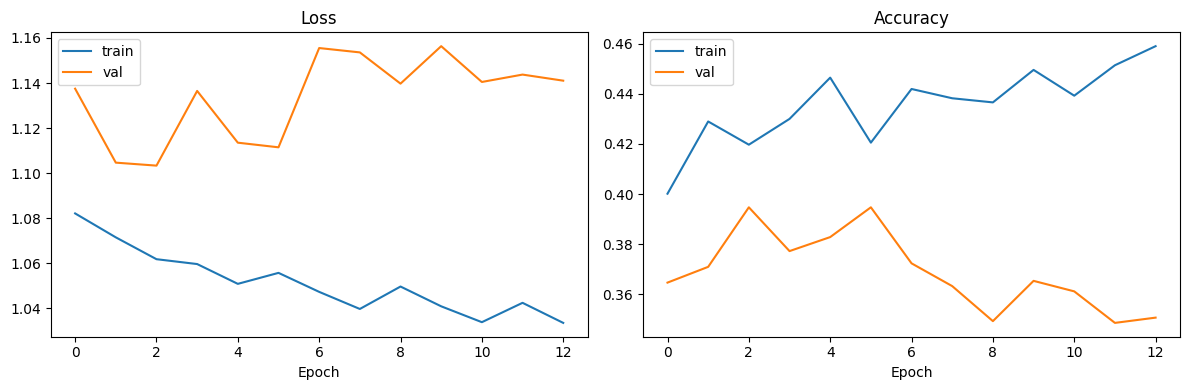

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/lstm_boredom_v1_training_curves.png', dpi=100)
plt.show()

## 8. Evaluación en Test

**Ojo con la comparación:** los benchmarks que citás en la tesis (64-67% LSTM, 73% ViBED-Net) son para clasificación de **Engagement en 4 niveles**, no para nuestro target de **Boredom en 3 niveles** — no son directamente comparables. Los reportamos igual como referencia de orden de magnitud, pero en la tesis hay que aclarar esta diferencia de tarea para no comparar peras con manzanas.

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

Test accuracy: 0.3687
Test loss: 1.1038
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step

Reporte de clasificación:
                     precision    recall  f1-score   support

             Atento      0.527     0.394     0.451       747
   Desatencion_leve      0.343     0.154     0.213       519
Desatencion_marcada      0.272     0.618     0.377       372

           accuracy                          0.369      1638
          macro avg      0.381     0.389     0.347      1638
       weighted avg      0.411     0.369     0.359      1638



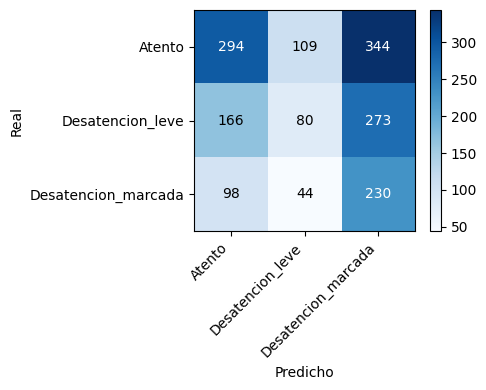

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/lstm_boredom_v1_confusion_matrix.png', dpi=100)
plt.show()

## 9. Guardar modelo final + scaler

El scaler es tan importante como el modelo: sin él, cualquier feature nuevo (por ejemplo, en producción dentro de la extensión) va a estar en la escala equivocada.

In [ ]:
import joblib

model.save(f'{MODELS_DIR}/lstm_boredom_v1_final.keras')
joblib.dump(scaler, f'{MODELS_DIR}/scaler_v1.pkl')

print('Modelo guardado en:', f'{MODELS_DIR}/lstm_boredom_v1_final.keras')
print('Scaler guardado en:', f'{MODELS_DIR}/scaler_v1.pkl')

## Checkpoint de la Fase 5+6

Pegame acá:
- El `classification_report` completo de la sección 8 (accuracy, precision/recall/F1 por clase).
- La matriz de confusión (o una descripción de qué se confunde con qué).
- Si el entrenamiento cortó por early stopping o llegó a las 100 épocas.

Con eso decidimos si el baseline es suficiente para la tesis o si conviene: (a) ajustar la arquitectura, (b) probar features adicionales (roll, velocidad de cambio de yaw/pitch entre frames), o (c) recién ahí evaluar sumar otro dataset.

In [11]:

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/SparkleV2'
DATASET_DIR = f'{PROJECT_DIR}/dataset_final'
MODELS_DIR = f'{PROJECT_DIR}/checkpoints'
os.makedirs(MODELS_DIR, exist_ok=True)

CLASS_NAMES = ['Atento', 'Desatencion_leve', 'Desatencion_marcada']

In [12]:
def load_split(split_name):
    data = np.load(f'{DATASET_DIR}/{split_name}_consolidado.npz', allow_pickle=True)
    return {
        'X': data['X'],
        'boredom': data['boredom'],
    }

train = load_split('train')
val = load_split('validation')
test = load_split('test')

def collapse_boredom(boredom_array):
    return np.where(boredom_array == 0, 0, np.where(boredom_array == 1, 1, 2)).astype(np.int32)

y_train = collapse_boredom(train['boredom'])
y_val = collapse_boredom(val['boredom'])
y_test = collapse_boredom(test['boredom'])

print('Shapes:', train['X'].shape, val['X'].shape, test['X'].shape)

Shapes: (4851, 60, 5) (1429, 60, 5) (1638, 60, 5)


In [13]:
majority_class = pd.Series(y_train).value_counts().idxmax()
trivial_preds = np.full_like(y_test, majority_class)
trivial_acc = accuracy_score(y_test, trivial_preds)
print(f'Clase mayoritaria (Train): {CLASS_NAMES[majority_class]}')
print(f'Accuracy del baseline trivial en Test: {trivial_acc:.4f}')
print('\nCualquier modelo que propongamos tiene que superar claramente este número para ser útil.')

Clase mayoritaria (Train): Atento
Accuracy del baseline trivial en Test: 0.4560

Cualquier modelo que propongamos tiene que superar claramente este número para ser útil.


In [14]:
def summarize_clip(X):
    # X: (n_clips, n_frames, n_features) -> (n_clips, n_features*4)
    mean = X.mean(axis=1)
    std = X.std(axis=1)
    minimum = X.min(axis=1)
    maximum = X.max(axis=1)
    return np.concatenate([mean, std, minimum, maximum], axis=1)

X_train_summary = summarize_clip(train['X'])
X_val_summary = summarize_clip(val['X'])
X_test_summary = summarize_clip(test['X'])

scaler_summary = StandardScaler()
X_train_summary_scaled = scaler_summary.fit_transform(X_train_summary)
X_val_summary_scaled = scaler_summary.transform(X_val_summary)
X_test_summary_scaled = scaler_summary.transform(X_test_summary)

print('Shape de features resumen:', X_train_summary_scaled.shape)

Shape de features resumen: (4851, 20)


In [15]:
print('--- Regresión Logística ---')
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='multinomial')
logreg.fit(X_train_summary_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_summary_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}')
print(classification_report(y_test, y_pred_logreg, target_names=CLASS_NAMES, digits=3))

--- Regresión Logística ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.3742
                     precision    recall  f1-score   support

             Atento      0.582     0.336     0.426       747
   Desatencion_leve      0.339     0.283     0.308       519
Desatencion_marcada      0.278     0.578     0.376       372

           accuracy                          0.374      1638
          macro avg      0.400     0.399     0.370      1638
       weighted avg      0.436     0.374     0.377      1638



In [16]:
print('--- Random Forest ---')
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_summary_scaled, y_train)
y_pred_rf = rf.predict(X_test_summary_scaled)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, digits=3))

--- Random Forest ---
Accuracy: 0.3956
                     precision    recall  f1-score   support

             Atento      0.531     0.482     0.505       747
   Desatencion_leve      0.348     0.291     0.317       519
Desatencion_marcada      0.260     0.368     0.305       372

           accuracy                          0.396      1638
          macro avg      0.380     0.380     0.376      1638
       weighted avg      0.412     0.396     0.400      1638



In [17]:
# Importancia de features del Random Forest — ayuda a ver qué variables cargan señal real
feature_labels = []
for stat in ['mean', 'std', 'min', 'max']:
    for f in ['ear_avg', 'ear_left', 'ear_right', 'yaw', 'pitch']:
        feature_labels.append(f'{f}_{stat}')

importances = pd.Series(rf.feature_importances_, index=feature_labels).sort_values(ascending=False)
print('Top 10 features más importantes según Random Forest:')
print(importances.head(10))

Top 10 features más importantes según Random Forest:
pitch_min        0.063529
pitch_mean       0.062196
pitch_max        0.058724
ear_left_mean    0.056445
pitch_std        0.053611
yaw_max          0.051295
ear_left_std     0.050827
ear_right_max    0.050671
ear_left_min     0.049629
yaw_std          0.048454
dtype: float64
